# Netflix Content Strategy Analysis using CRISP-DM

## Business Problem

Netflix invests billions of dollars each year in acquiring and producing content. Despite this investment, subscriber growth has slowed in several regions and customer retention remains a major business challenge.

The objective of this project is to analyze Netflix's content library to identify patterns in content distribution, regional representation, genre diversity, and release trends. These insights will help recommend strategies for improving engagement and guiding future content investments.

---

## Business Objectives

- Understand Netflix's content portfolio.
- Analyze content distribution across countries.
- Compare Movies and TV Shows.
- Identify dominant genres.
- Discover regional content gaps.
- Generate business recommendations based on data.

---

## Success Criteria

- Produce meaningful business insights.
- Identify content gaps.
- Recommend future investment strategies.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [7]:
df = pd.read_csv("data/netflix_titles.csv")

In [8]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [9]:
df.shape

(8807, 12)

In [10]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [12]:
df.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [13]:
missing = df.isnull().sum().sort_values(ascending=False)

missing

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

In [14]:
missing_percent = (df.isnull().sum()/len(df))*100

missing_percent.sort_values(ascending=False)

director        29.908028
country          9.435676
cast             9.367549
date_added       0.113546
rating           0.045418
duration         0.034064
show_id          0.000000
type             0.000000
title            0.000000
release_year     0.000000
listed_in        0.000000
description      0.000000
dtype: float64

In [15]:
df.duplicated().sum()

np.int64(0)

### Observation

The dataset contains missing values primarily in:

• Director
• Cast
• Country

This is expected because not every content item has complete metadata.

Business Impact

Incomplete metadata can reduce the effectiveness of recommendation systems and content analytics.

# Data Preparation

In this phase, we clean the dataset and prepare it for analysis.

The main tasks include:

- Removing duplicate records
- Handling missing values
- Converting data types
- Creating new features
- Standardizing data for analysis

These steps ensure the dataset is accurate, consistent, and suitable for generating business insights.

In [16]:
df_clean = df.copy()

In [17]:
df_clean.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [18]:
duplicates = df_clean.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [19]:
df_clean.drop_duplicates(inplace=True)

print(df_clean.shape)

(8807, 12)


## Business Insight
Duplicate records were removed to ensure that every content item is counted only once. This prevents biased business insights and inaccurate visualizations.

In [20]:
df_clean["director"] = df_clean["director"].fillna("Unknown")

df_clean["cast"] = df_clean["cast"].fillna("Unknown")

df_clean["country"] = df_clean["country"].fillna("Unknown")

df_clean["rating"] = df_clean["rating"].fillna("Not Rated")

In [26]:
df_clean["date_added"] = df_clean["date_added"].str.strip()

In [27]:
df_clean["date_added"] = pd.to_datetime(
    df_clean["date_added"],
    format="%B %d, %Y",
    errors="coerce"
)

In [28]:
df_clean["date_added"].isna().sum()

np.int64(0)

In [29]:
df_clean[df_clean["date_added"].isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


In [30]:
df_clean = df_clean.dropna(subset=["date_added"])

Missing values were handled strategically instead of deleting entire rows.

Business reasoning:

• Unknown directors are still valuable content.

• Unknown cast members should not remove a movie from analysis.

• Country information may be unavailable for older titles.

Only rows missing "Date Added" were removed because timeline analysis depends on this information.

In [31]:
df_clean["date_added"] = pd.to_datetime(df_clean["date_added"])

In [32]:
df_clean["year_added"] = df_clean["date_added"].dt.year

In [33]:
df_clean["month_added"] = df_clean["date_added"].dt.month_name()

In [34]:
df_clean["day_added"] = df_clean["date_added"].dt.day_name()

In [35]:
df_clean.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,day_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,September,Saturday
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,September,Friday
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,September,Friday
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,September,Friday
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,September,Friday


In [36]:
CURRENT_YEAR = 2026

df_clean["content_age"] = CURRENT_YEAR - df_clean["release_year"]

In [37]:
df_clean["decade"] = (df_clean["release_year"] // 10) * 10

In [38]:
df_clean["primary_country"] = df_clean["country"].str.split(",").str[0].str.strip()

In [39]:
df_clean["primary_genre"] = df_clean["listed_in"].str.split(",").str[0].str.strip()

In [41]:
# Create the column
df_clean["duration_minutes"] = np.nan

# Fill only movie rows
movie_mask = df_clean["type"] == "Movie"

df_clean.loc[movie_mask, "duration_minutes"] = (
    df_clean.loc[movie_mask, "duration"]
    .str.extract(r"(\d+)")[0]
    .astype(float)
)

In [42]:
df_clean[["type","duration","duration_minutes"]].head()

,type,duration,duration_minutes
0,Movie,90 min,90.0
1,TV Show,2 Seasons,NaN
2,TV Show,1 Season,NaN
3,TV Show,1 Season,NaN
4,TV Show,2 Seasons,NaN


In [43]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   show_id           8797 non-null   object        
 1   type              8797 non-null   object        
 2   title             8797 non-null   object        
 3   director          8797 non-null   object        
 4   cast              8797 non-null   object        
 5   country           8797 non-null   object        
 6   date_added        8797 non-null   datetime64[ns]
 7   release_year      8797 non-null   int64         
 8   rating            8797 non-null   object        
 9   duration          8794 non-null   object        
 10  listed_in         8797 non-null   object        
 11  description       8797 non-null   object        
 12  year_added        8797 non-null   int32         
 13  month_added       8797 non-null   object        
 14  day_added         8797 non-nu

In [44]:
df_clean.isnull().sum()

show_id                0
type                   0
title                  0
director               0
cast                   0
country                0
date_added             0
release_year           0
rating                 0
duration               3
listed_in              0
description            0
year_added             0
month_added            0
day_added              0
content_age            0
decade                 0
primary_country        0
primary_genre          0
duration_minutes    2669
dtype: int64

In [45]:
df_clean.to_csv("../data/netflix_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## Data Preparation Summary

The dataset was cleaned by:

- Removing duplicate records.
- Filling missing values with meaningful defaults.
- Converting dates into datetime format.
- Creating analytical features such as:
  - Year Added
  - Month Added
  - Day Added
  - Content Age
  - Decade
  - Primary Country
  - Primary Genre
  - Duration in Minutes

The cleaned dataset is now ready for exploratory data analysis and business insight generation.

# Exploratory Data Analysis (EDA)

The objective of this phase is to explore the cleaned dataset, identify meaningful patterns, and answer the business questions defined during the Business Understanding phase.

Each visualization is followed by business insights and actionable recommendations for Netflix.

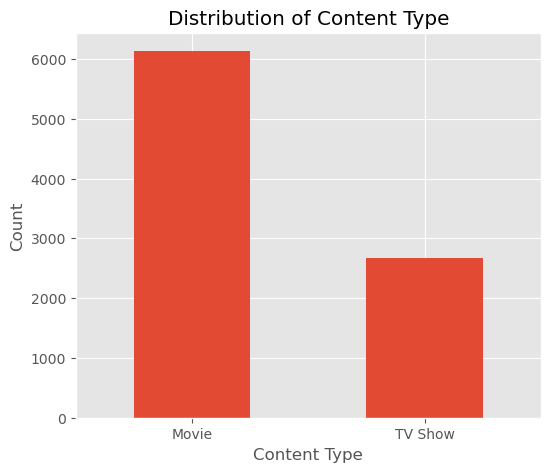

In [46]:
content_counts = df_clean["type"].value_counts()

plt.figure(figsize=(6,5))

content_counts.plot(
    kind="bar",
    rot=0
)

plt.title("Distribution of Content Type")
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.show()

Netflix's library is dominated by Movies.

Although Movies are easier to produce and acquire,
TV Shows generally keep subscribers engaged for longer
because viewers return for multiple episodes and seasons.

### Recommendation
Increase investment in high-quality TV Series
to improve customer retention.

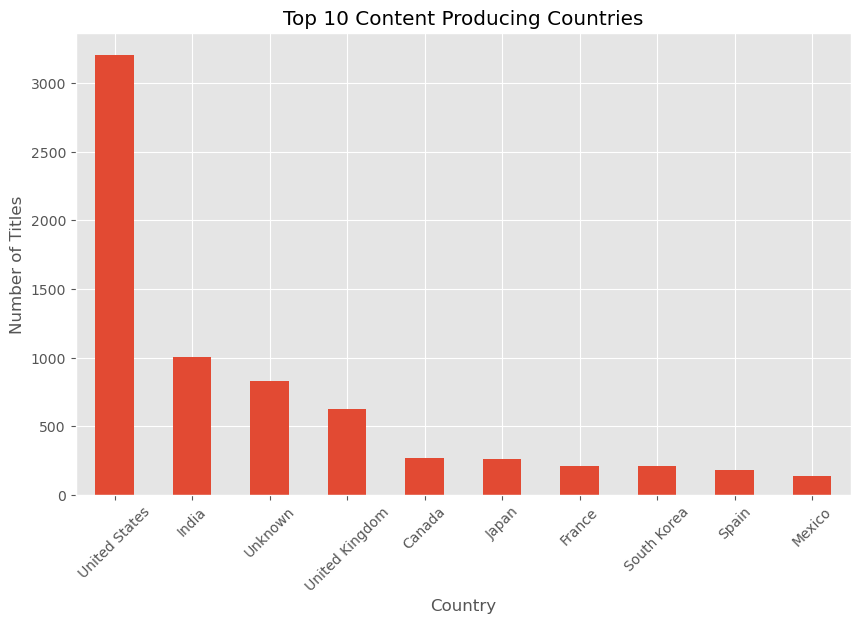

In [47]:
top_countries = df_clean["primary_country"].value_counts().head(10)

plt.figure(figsize=(10,6))

top_countries.plot(kind="bar")

plt.title("Top 10 Content Producing Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

The United States contributes the largest amount
of Netflix content, followed by India and the UK.

This indicates a heavy dependence on a few regions.

### Recommendation
Expand investments in Africa,
South America,
and Southeast Asia
to improve global market penetration.

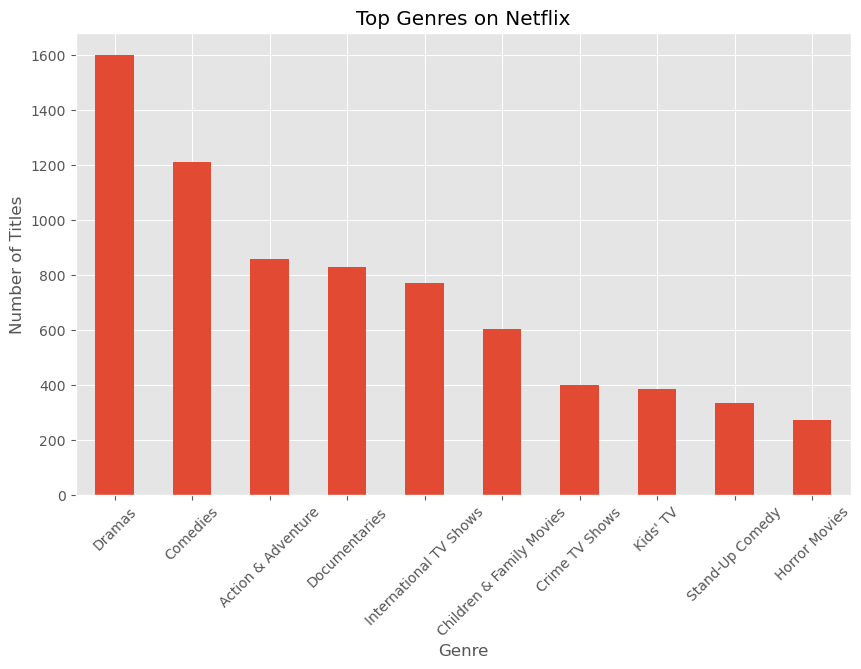

In [48]:
top_genres = df_clean["primary_genre"].value_counts().head(10)

plt.figure(figsize=(10,6))

top_genres.plot(kind="bar")

plt.title("Top Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

Drama,
International Movies,
Comedy

dominate the platform.

Genres such as Science,
Technology,
and Educational content
are underrepresented.

### Recommendation
Diversify investments into
Educational,
Science,
and Technology programming.

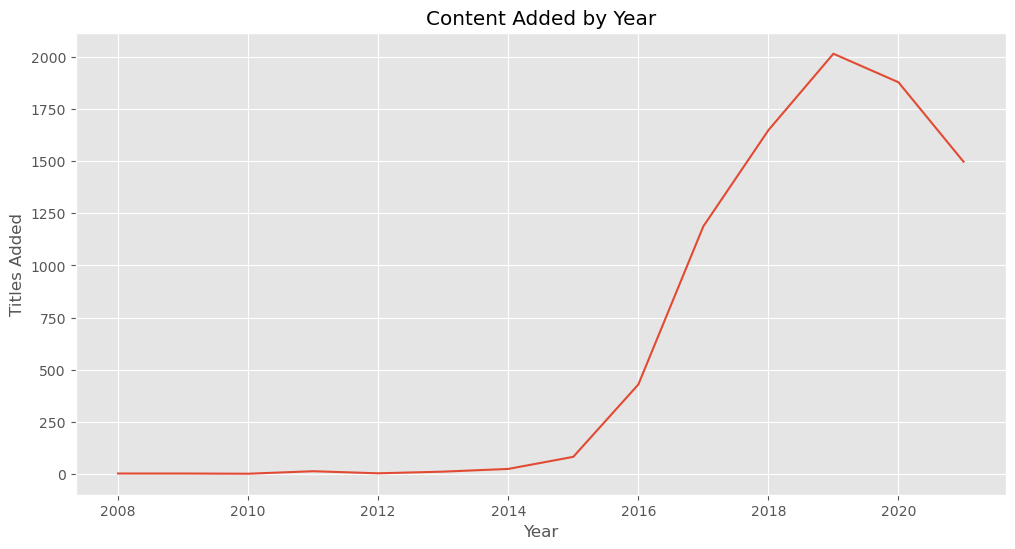

In [49]:
year_added = df_clean["year_added"].value_counts().sort_index()

plt.figure(figsize=(12,6))

year_added.plot()

plt.title("Content Added by Year")
plt.xlabel("Year")
plt.ylabel("Titles Added")

plt.show()

Netflix experienced rapid growth
after 2015,
indicating aggressive global expansion.

### Recommendation
Analyze post-2020 investment trends
to determine whether content acquisition
should increase again.

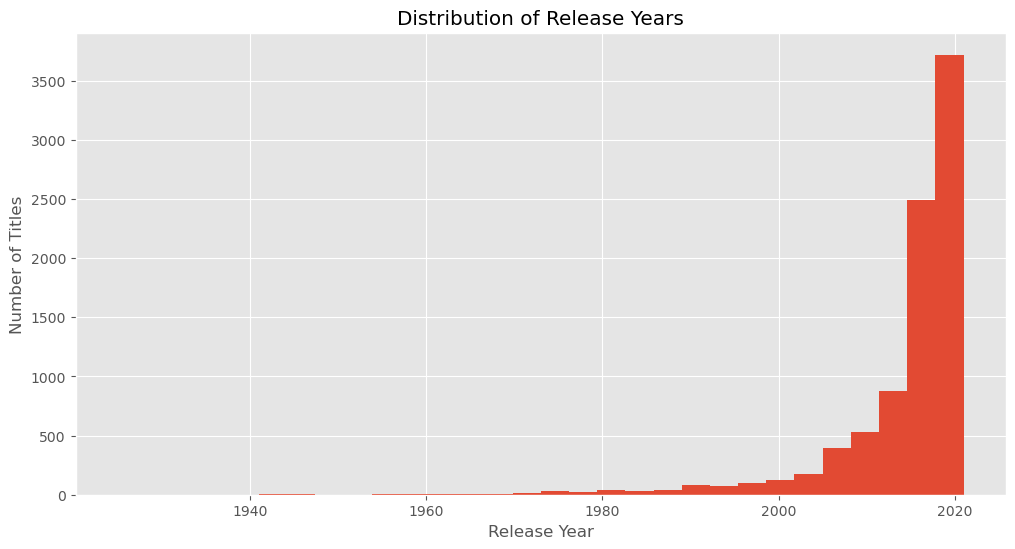

In [50]:
plt.figure(figsize=(12,6))

df_clean["release_year"].hist(
    bins=30
)

plt.title("Distribution of Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

Most Netflix titles are relatively recent,
reflecting a focus on modern audiences.

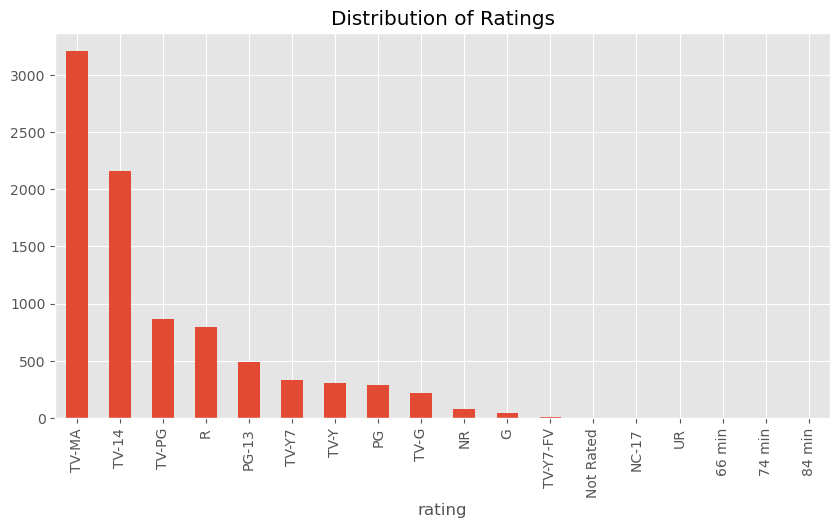

In [51]:
ratings = df_clean["rating"].value_counts()

plt.figure(figsize=(10,5))

ratings.plot(kind="bar")

plt.title("Distribution of Ratings")

plt.show()

Most content is rated

TV-MA

and

TV-14.

Netflix primarily targets adult audiences.

### Recommendation
Increase family-friendly
and children's programming
to broaden audience reach.

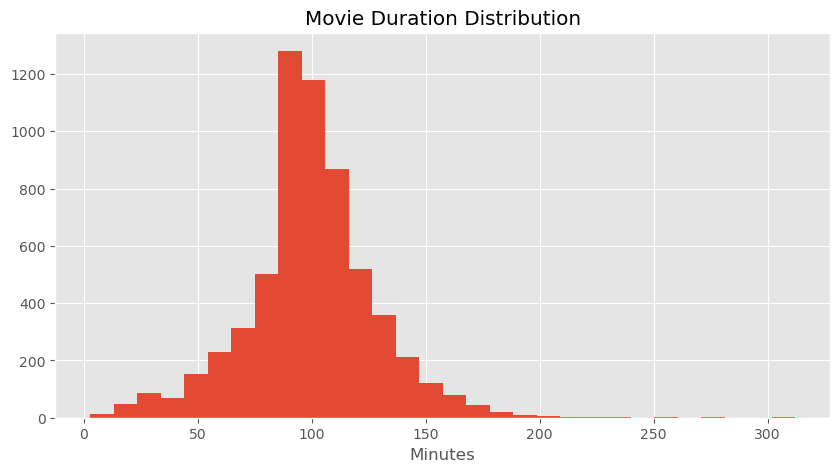

In [52]:
movies = df_clean[df_clean["type"]=="Movie"]

plt.figure(figsize=(10,5))

movies["duration_minutes"].hist(bins=30)

plt.title("Movie Duration Distribution")

plt.xlabel("Minutes")

plt.show()

Most movies range between
90 and 110 minutes.

This aligns with audience preferences
for standard-length films.

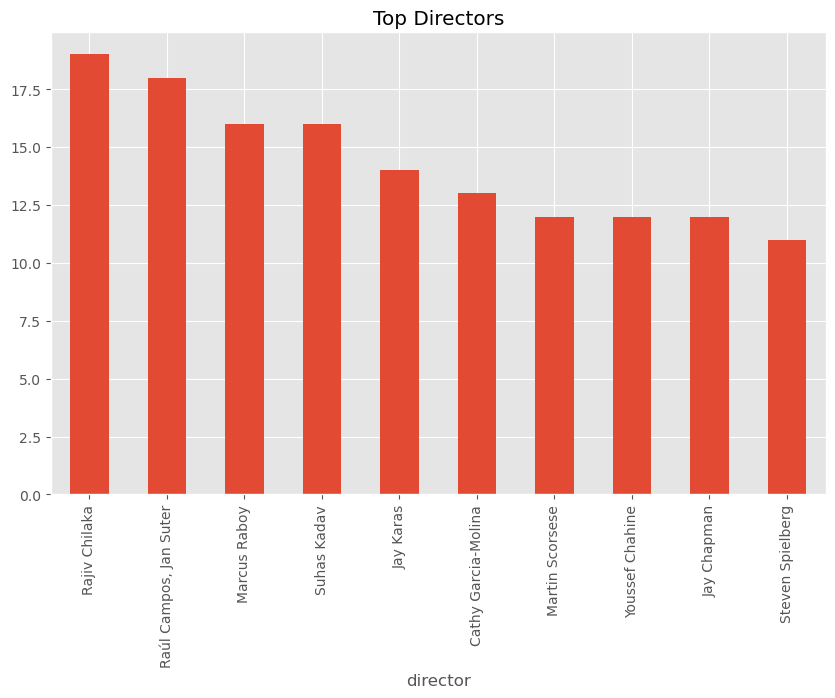

In [53]:
top_directors = (
    df_clean[df_clean["director"]!="Unknown"]["director"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

top_directors.plot(kind="bar")

plt.title("Top Directors")

plt.show()

A relatively small number of directors
contribute many titles.

Netflix may benefit from expanding
its partnerships with emerging filmmakers.

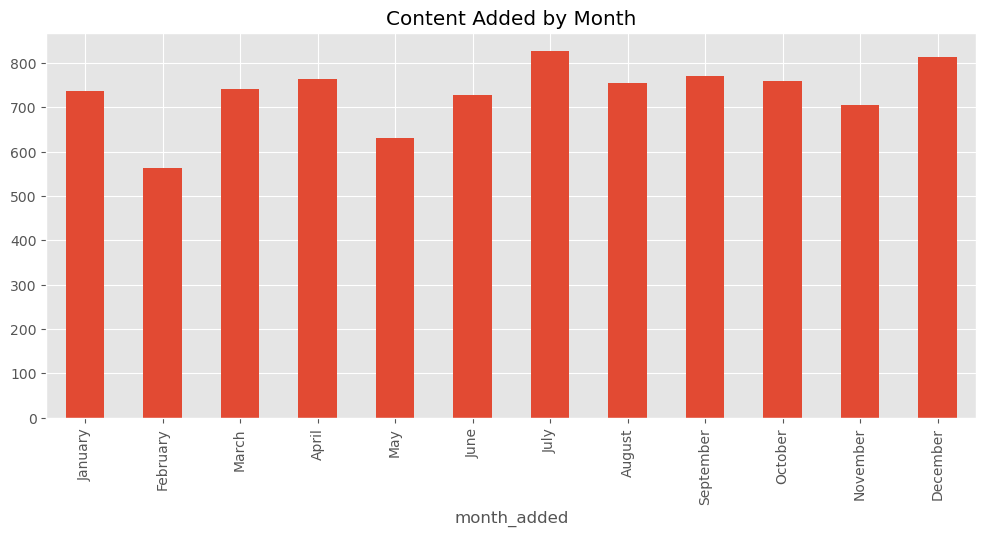

In [54]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly = (
    df_clean["month_added"]
    .value_counts()
    .reindex(month_order)
)

plt.figure(figsize=(12,5))

monthly.plot(kind="bar")

plt.title("Content Added by Month")

plt.show()

Certain months consistently
receive more content releases.

These periods likely align
with subscriber acquisition strategies.

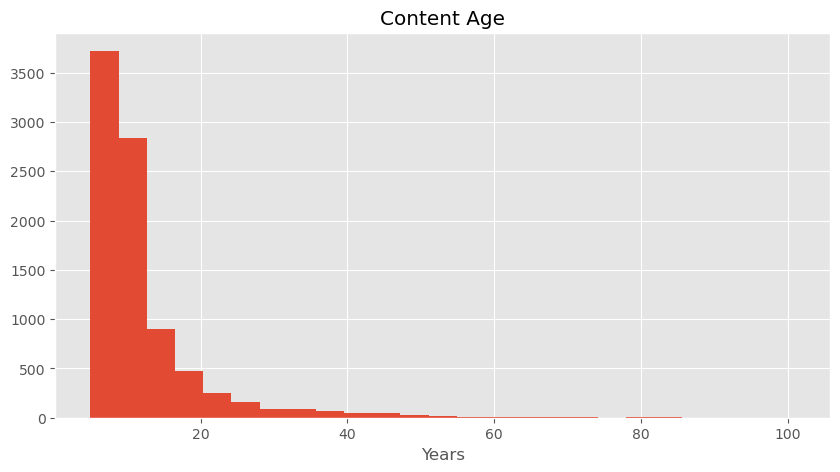

In [55]:
plt.figure(figsize=(10,5))

df_clean["content_age"].hist(
    bins=25
)

plt.title("Content Age")

plt.xlabel("Years")

plt.show()

Most content is less than
10 years old,
demonstrating Netflix's emphasis
on contemporary media.

# Business Summary
## Key Business Findings

- Movies dominate Netflix's catalog.
- Content production is concentrated in a few countries.
- Drama and International Movies are the most common genres.
- Most content targets adult audiences.
- The majority of movies are approximately 100 minutes long.
- Netflix's content library expanded rapidly after 2015.
- Several regions remain underrepresented.
- Educational and Science content are relatively scarce.

# Business Recommendations

1. Increase investment in TV Shows to improve subscriber retention.

2. Expand content production in underrepresented regions.

3. Diversify genres by investing in educational and science-related programming.

4. Strengthen the family-friendly content portfolio.

5. Collaborate with emerging directors to broaden creative diversity.

6. Continue analyzing content acquisition trends to optimize investments.